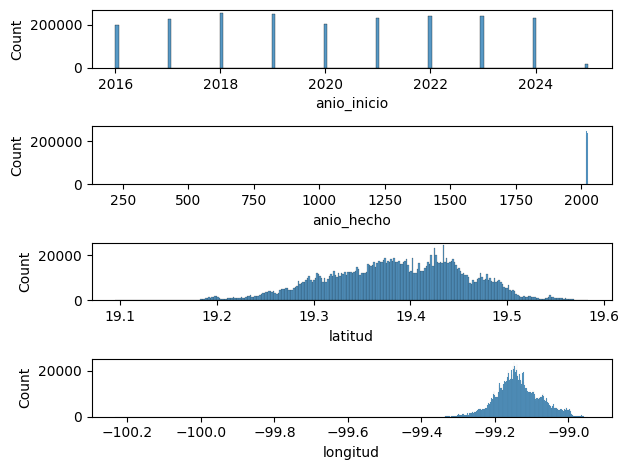

In [ ]:
# plot numeric features for data quality check and exploration
num_numeric_features = len(numeric_features)

fig_raw_num_feats, axes_raw_num_feats = plt.subplots(num_numeric_features) # create subplot for numeric features (3)
for i in range(num_numeric_features):
    sns.histplot(data[numeric_features[i]], ax=axes_raw_num_feats[i]) # using for loop through numeric features list to create histogram for each feature
plt.tight_layout()

Since column "anio_hecho" exposes an atypical distribution, is interesting to explore its values. In the other hand "latitud" and "longitud" correspond to geographic positions, indicating that there should be more reports of crime in certain areas.

In [ ]:
# raw unique values of anio hecho
print("raw unique values:", data["anio_hecho"].unique())

data["anio_hecho"].value_counts(dropna=False).sort_index() # counts of unique values including NaN

raw unique values: <FloatingArray>
[2015.0, 2016.0, 2014.0, 2008.0, 2012.0, 2011.0, 2013.0, 1997.0, 2009.0,
   <NA>, 2006.0, 2017.0, 2000.0, 2007.0, 2001.0, 2010.0, 2004.0, 1965.0,
 1985.0, 2003.0, 2005.0, 1987.0, 2002.0, 1998.0, 1996.0, 1986.0, 1955.0,
 1983.0, 1995.0, 1991.0, 1999.0, 1994.0, 1956.0, 1979.0, 1992.0, 1958.0,
 1966.0, 1930.0, 1915.0, 1989.0, 1984.0, 1978.0, 1975.0, 1993.0, 1976.0,
 1962.0, 1970.0, 1972.0, 1990.0, 1988.0, 1973.0, 1977.0, 1960.0, 1969.0,
 1974.0, 1980.0, 1982.0, 1981.0, 1964.0, 2018.0, 1971.0, 1957.0, 2019.0,
 1968.0, 1963.0, 2020.0, 1950.0, 1952.0, 2021.0, 1961.0, 1917.0, 2022.0,
  222.0, 1942.0, 1906.0, 1954.0, 1967.0, 2023.0, 2024.0, 2025.0]
Length: 80, dtype: Float64


anio_hecho
222.00           1
1,906.00         1
1,915.00         2
1,917.00         1
1,930.00         1
             ...  
2,022.00    237868
2,023.00    237440
2,024.00    216965
2,025.00     12516
 <NA>          559
Name: count, Length: 80, dtype: Int64

#### Column values exploration
Check unique values for all columns and null registrys to understand what does each column means

In [ ]:
def extract_unique_values_summary(df):
    """
    Extracts unique values and their counts for all columns in a DataFrame.
    
    Returns a dictionary with structure:
    {
        "column_name": {
            "unique_count": int,
            "null_count": int,
            "data_type": str,
            "value_counts": {"value": count, ...}
        }
    }
    """
    summary = {}
    
    for col in df.columns:
        value_counts = df[col].value_counts(dropna=False)
        null_count = df[col].isna().sum()
        
        # Convert to serializable dict
        value_counts_dict = {}
        for key, val in value_counts.items():
            # Check if key is NaN
            if pd.isna(key):
                value_counts_dict['<NULL>'] = int(val)
            else:
                value_counts_dict[str(key)] = int(val)
        
        summary[col] = {
            "unique_count": df[col].nunique(),
            "null_count": int(null_count),
            "data_type": str(df[col].dtype),
            "value_counts": value_counts_dict
        }
    
    return summary

# Extract summary from loaded data
unique_summary = extract_unique_values_summary(data)

print(f"Extracted unique values for {len(unique_summary)} columns")


Extracted unique values for 21 columns


In [ ]:
# Export to JSON for reference
output_dir = Path("../data")
output_file = output_dir / "unique_values_summary.json"

with open(output_file, 'w', encoding='utf-8') as f:
    json.dump(unique_summary, f, indent=2, ensure_ascii=False)

print(f"Exported unique values summary to: {output_file.resolve()}")


Exported unique values summary to: C:\Users\adolh\Documents\8voUltimosPeriodos\notebooksReto\proy-8-grupo501-learning-latent-urban-representation\data\unique_values_summary.json


# HASTA AQUI LLEGA NICOLE EN EL EDA

# AQUI EMPIEZA NICOLE EN FASE 2

In [ ]:
# ============================================================================
# PASO 4: Ensamblar firma completa
# ============================================================================
print(f"Ensamblando firmas...")

firmas = pd.concat([
    delito_props,      # ~26 dims
    hora_props,        # 6 dims
    dia_props,         # 7 dims
    trim_props,        # 4 dims
    intensidad,        # 1 dim
    ratio_violencia,   # 1 dim
], axis=1)

# Verificar
print(f"\n{'='*80}")
print(f"FIRMA ESPACIO-TEMPORAL — RESUMEN")
print(f"{'='*80}")
print(f"  Hexágonos: {len(firmas):,}")
print(f"  Dimensiones: {firmas.shape[1]}")
print(f"  Nulos totales: {firmas.isna().sum().sum()}")

print(f"\n  Composición de la firma:")
print(f"    Mezcla de delitos:   {len(delito_props.columns)} dims")
print(f"    Perfil horario:      {len(hora_props.columns)} dims")
print(f"    Perfil semanal:      {len(dia_props.columns)} dims")
print(f"    Estacionalidad:      {len(trim_props.columns)} dims")
print(f"    Intensidad:          1 dim")
print(f"    Ratio violencia:     1 dim")
print(f"    TOTAL:               {firmas.shape[1]} dims")

# Estadísticas descriptivas rápidas
print(f"\n  Intensidad (log registros):")
print(f"    Min:  {firmas['intensidad_log'].min():.2f} ({np.expm1(firmas['intensidad_log'].min()):.0f} registros)")
print(f"    P50:  {firmas['intensidad_log'].median():.2f} ({np.expm1(firmas['intensidad_log'].median()):.0f} registros)")
print(f"    Max:  {firmas['intensidad_log'].max():.2f} ({np.expm1(firmas['intensidad_log'].max()):.0f} registros)")

print(f"\n  Ratio de violencia:")
print(f"    Min:  {firmas['ratio_violencia'].min():.3f}")
print(f"    P50:  {firmas['ratio_violencia'].median():.3f}")
print(f"    Max:  {firmas['ratio_violencia'].max():.3f}")

# Top 5 macro-categorías por peso promedio
print(f"\n  Macro-categorías con mayor peso promedio en las firmas:")
delito_cols = [c for c in firmas.columns if c.startswith('delito_')]
promedios = firmas[delito_cols].mean().sort_values(ascending=False)
for col, val in promedios.head(8).items():
    nombre = col.replace('delito_', '').replace('_', ' ').upper()
    print(f"    {nombre:45s} {val:.3f} ({val*100:.1f}%)")

# ============================================================================
# PASO 5: Metadatos por hexágono (para interpretación en etapa 5.4)
# ============================================================================
print(f"\nGenerando metadatos por hexágono...")

# Alcaldía dominante
alcaldia_dom = df_h3.groupby('h3_id')['alcaldia_hecho'].agg(
    lambda x: x.value_counts().index[0] if len(x) > 0 else 'DESCONOCIDA'
).rename('alcaldia_dominante')

# Colonia dominante
colonia_dom = df_h3.groupby('h3_id')['colonia_hecho'].agg(
    lambda x: x.dropna().value_counts().index[0] if len(x.dropna()) > 0 else 'DESCONOCIDA'
).rename('colonia_dominante')

# Centro del hexágono (para mapeo)
centros = pd.DataFrame(
    [h3.cell_to_latlng(h) for h in firmas.index],
    index=firmas.index,
    columns=['lat_centro', 'lon_centro']
)

# Conteo total
conteo_df = conteo_total.rename('n_registros')

metadata = pd.concat([alcaldia_dom, colonia_dom, centros, conteo_df], axis=1)
metadata = metadata.reindex(firmas.index)

# Distribución por alcaldía
print(f"\n  Hexágonos por alcaldía:")
for alc, count in metadata['alcaldia_dominante'].value_counts().head(16).items():
    print(f"    {alc:30s} {count:>5} hexágonos")

# ============================================================================
# PASO 6: Exportar
# ============================================================================
# 6a. Firmas
firmas.index.name = 'h3_id'
firmas.to_csv('firmas_h3.csv', encoding='utf-8-sig')
print(f"\n✓ firmas_h3.csv ({len(firmas):,} hexágonos × {firmas.shape[1]} dimensiones)")

# 6b. Metadatos
metadata.index.name = 'h3_id'
metadata.to_csv('h3_metadata.csv', encoding='utf-8-sig')
print(f"✓ h3_metadata.csv ({len(metadata):,} hexágonos)")

# 6c. Dataset con h3_id
df_valid['h3_id'] = df_valid.apply(
    lambda row: h3.latlng_to_cell(row['latitud'], row['longitud'], H3_RESOLUTION),
    axis=1
)
df_valid.to_csv('carpetasFGJ_fase2_h3.csv', index=False, encoding='utf-8-sig')
print(f"carpetasFGJ_fase2_h3.csv ({len(df_valid):,} registros)")


# FASE 3

In [ ]:
# ============================================================================
# PASO 3: AUTOENCODER DENSO
# ============================================================================
print(f"\n{'='*80}")
print(f"MÉTODO B: AUTOENCODER DENSO")
print(f"{'='*80}")

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Arquitectura
INPUT_DIM = X_std.shape[1]  # 45
ENCODING_DIM = 12  # embedding de salida
HIDDEN_DIMS = [32, 24]  # capas intermedias

class CrimeAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dims, encoding_dim):
        super().__init__()
        
        # Encoder
        encoder_layers = []
        prev_dim = input_dim
        for h_dim in hidden_dims:
            encoder_layers.extend([
                nn.Linear(prev_dim, h_dim),
                nn.BatchNorm1d(h_dim),
                nn.ReLU(),
                nn.Dropout(0.1)
            ])
            prev_dim = h_dim
        encoder_layers.append(nn.Linear(prev_dim, encoding_dim))
        self.encoder = nn.Sequential(*encoder_layers)
        
        # Decoder (simétrico)
        decoder_layers = []
        prev_dim = encoding_dim
        for h_dim in reversed(hidden_dims):
            decoder_layers.extend([
                nn.Linear(prev_dim, h_dim),
                nn.BatchNorm1d(h_dim),
                nn.ReLU(),
                nn.Dropout(0.1)
            ])
            prev_dim = h_dim
        decoder_layers.append(nn.Linear(prev_dim, input_dim))
        self.decoder = nn.Sequential(*decoder_layers)
    
    def encode(self, x):
        return self.encoder(x)
    
    def decode(self, z):
        return self.decoder(z)
    
    def forward(self, x):
        z = self.encode(x)
        x_recon = self.decode(z)
        return x_recon, z

# Preparar datos
X_tensor = torch.FloatTensor(X_std)
dataset = TensorDataset(X_tensor, X_tensor)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

# Entrenar
model = CrimeAutoencoder(INPUT_DIM, HIDDEN_DIMS, ENCODING_DIM)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=20, factor=0.5)
criterion = nn.MSELoss()

EPOCHS = 300
best_loss = float('inf')
patience_counter = 0
PATIENCE = 50

print(f"  Arquitectura: {INPUT_DIM} → {HIDDEN_DIMS} → {ENCODING_DIM} → {list(reversed(HIDDEN_DIMS))} → {INPUT_DIM}")
print(f"  Entrenando ({EPOCHS} epochs max, early stopping patience={PATIENCE})...")

losses = []
for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    for batch_x, _ in dataloader:
        optimizer.zero_grad()
        x_recon, z = model(batch_x)
        loss = criterion(x_recon, batch_x)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(dataloader)
    losses.append(avg_loss)
    scheduler.step(avg_loss)
    
    if avg_loss < best_loss:
        best_loss = avg_loss
        patience_counter = 0
        best_state = model.state_dict().copy()
    else:
        patience_counter += 1
    
    if patience_counter >= PATIENCE:
        print(f"  Early stopping en epoch {epoch+1}")
        break
    
    if (epoch + 1) % 50 == 0:
        print(f"    Epoch {epoch+1:3d}: loss = {avg_loss:.6f}")

# Cargar mejor modelo
model.load_state_dict(best_state)
print(f"  Mejor loss: {best_loss:.6f}")

# Extraer embeddings
model.eval()
with torch.no_grad():
    x_recon, embeddings_ae = model(X_tensor)
    recon_error = torch.mean((X_tensor - x_recon) ** 2, dim=1).numpy()

X_ae = embeddings_ae.numpy()
print(f"  Embeddings shape: {X_ae.shape}")
print(f"  Error de reconstrucción medio: {recon_error.mean():.4f}")
print(f"  Error de reconstrucción máximo: {recon_error.max():.4f}")

# Guardar modelo
torch.save(best_state, 'modelo_autoencoder.pth')
print(f"  ✓ Modelo guardado: modelo_autoencoder.pth")